# F1 2026: прогноз особистого чемпіонату за підсумками половини сезону

**Мета:** побудувати модель, яка оцінює шанси пілотів на титул за даними перших 11 етапів сезону 2026.

**Чому саме цей сезон і саме зараз.** 2026 — рік зміни технічного регламенту. Це означає, що
результати попередніх сезонів як основа для прогнозу не працюють: машини інші, силові установки інші,
розстановка сил інша. Літня пауза дає те, чого не було на старті року — половину сезону реальних даних
нового регламенту.

**Джерело даних:** [OpenF1 API](https://openf1.org) → PostgreSQL → CSV.
Особистий залік, порахований із цих даних, збігається з незалежним джерелом (Jolpica/Ergast) до очка.

**Структура роботи:**
1. Завантаження та очищення даних
2. Описова статистика (EDA)
3. Перевірка гіпотез
4. Моделювання та прогноз

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

BLUE, GREEN, RED = "#4C72B0", "#55A868", "#C44E52"

## Частина 1: Завантаження та Очищення Даних

Дані вивантажені з PostgreSQL у CSV, щоб роботу можна було відтворити без доступу до бази.
Основна таблиця — один рядок на пілота в одній гонці.

In [2]:
df_raw   = pd.read_csv("export/f1_2026_race_analysis.csv")
laps_raw = pd.read_csv("export/star/fact_lap.csv")
res_raw  = pd.read_csv("export/star/fact_result.csv")
ses_raw  = pd.read_csv("export/star/dim_session.csv")
mee_raw  = pd.read_csv("export/star/dim_meeting.csv")
drv_raw  = pd.read_csv("export/star/dim_driver.csv")

print("гонки:", df_raw.shape, "| кола:", laps_raw.shape, "| результати:", res_raw.shape)
df_raw.head()

гонки: (721, 29) | кола: (110430, 30) | результати: (3782, 16)


,year,round,meeting_name,circuit,is_street,driver,driver_code,team,driver_number,quali_position,finish_position,points,dnf,dsq,number_of_laps,total_laps,clean_laps,median_clean_lap_s,best_lap_s,gap_to_leader_s,laps_down,pit_stops,compounds_used,overtakes_made,track_temp_avg,track_temp_max,air_temp_avg,humidity_avg,rainfall_max
0,2025,1,Australian Grand Prix,Melbourne,t,Lando NORRIS,NOR,McLaren,4,1.0,1.0,25.0,f,f,57.0,62.0,37.0,90.146,82.167,0.000,NaN,5.0,HARD+INTERMEDIATE,9.0,18.9,19.4,15.7,78.4,1
1,2025,1,Australian Grand Prix,Melbourne,t,Max VERSTAPPEN,VER,Red Bull Racing,1,3.0,2.0,18.0,f,f,57.0,62.0,35.0,90.845,83.081,0.895,NaN,5.0,INTERMEDIATE+MEDIUM,8.0,18.9,19.4,15.7,78.4,1
2,2025,1,Australian Grand Prix,Melbourne,t,George RUSSELL,RUS,Mercedes,63,4.0,3.0,15.0,f,f,57.0,62.0,36.0,91.152,85.065,8.481,NaN,5.0,HARD+INTERMEDIATE,7.0,18.9,19.4,15.7,78.4,1
3,2025,1,Australian Grand Prix,Melbourne,t,Kimi ANTONELLI,ANT,Mercedes,12,16.0,4.0,12.0,f,f,57.0,62.0,36.0,91.322,84.901,10.135,NaN,5.0,HARD+INTERMEDIATE,17.0,18.9,19.4,15.7,78.4,1
4,2025,1,Australian Grand Prix,Melbourne,t,Alexander ALBON,ALB,Williams,23,6.0,5.0,10.0,f,f,57.0,62.0,36.0,92.045,84.597,12.773,NaN,5.0,INTERMEDIATE+MEDIUM,8.0,18.9,19.4,15.7,78.4,1


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                721 non-null    int64  
 1   round               721 non-null    int64  
 2   meeting_name        721 non-null    str    
 3   circuit             721 non-null    str    
 4   is_street           721 non-null    str    
 5   driver              721 non-null    str    
 6   driver_code         721 non-null    str    
 7   team                721 non-null    str    
 8   driver_number       721 non-null    int64  
 9   quali_position      709 non-null    float64
 10  finish_position     618 non-null    float64
 11  points              721 non-null    float64
 12  dnf                 721 non-null    str    
 13  dsq                 721 non-null    str    
 14  number_of_laps      715 non-null    float64
 15  total_laps          698 non-null    float64
 16  clean_laps         

In [4]:
df_raw.describe()

,year,round,driver_number,quali_position,finish_position,points,number_of_laps,total_laps,clean_laps,median_clean_lap_s,best_lap_s,gap_to_leader_s,laps_down,pit_stops,overtakes_made,track_temp_avg,track_temp_max,air_temp_avg,humidity_avg,rainfall_max
count,721.000000,721.000000,721.000000,709.000000,618.000000,721.000000,715.000000,698.000000,674.000000,674.000000,674.000000,443.000000,167.000000,677.000000,702.000000,721.000000,721.00000,721.000000,721.000000,721.000000
mean,2025.335645,10.811373,30.030513,10.669958,9.406149,4.902913,54.588811,55.786533,47.286350,89.738266,87.674978,38.976366,1.401198,1.859675,12.163818,35.468377,39.00638,23.492510,52.753121,0.196949
std,0.472543,6.536261,25.128706,5.911395,5.223227,7.123241,17.259963,14.955851,13.494467,10.528930,10.524118,28.699361,1.414469,1.110513,7.764927,10.072665,9.84360,5.466293,18.336693,0.397969
min,2025.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,69.520000,67.924000,0.000000,1.000000,1.000000,1.000000,17.800000,19.10000,12.800000,18.200000,0.000000
25%,2025.000000,6.000000,10.000000,6.000000,5.000000,0.000000,51.000000,51.000000,42.000000,81.849500,79.850500,14.844500,1.000000,1.000000,7.000000,28.000000,29.60000,18.000000,37.800000,0.000000
50%,2025.000000,10.000000,23.000000,11.000000,9.000000,0.000000,57.000000,56.000000,49.000000,90.077500,87.483500,33.808000,1.000000,2.000000,11.000000,35.800000,39.10000,24.000000,54.600000,0.000000
75%,2026.000000,15.000000,44.000000,16.000000,14.000000,8.000000,67.000000,67.000000,57.000000,97.147750,95.173500,61.820500,1.000000,2.000000,16.000000,43.300000,46.00000,27.200000,70.400000,0.000000
max,2026.000000,24.000000,87.000000,22.000000,20.000000,25.000000,78.000000,78.000000,68.000000,140.966000,140.966000,110.925000,15.000000,7.000000,101.000000,50.600000,53.30000,34.500000,84.400000,1.000000


### Проблема, яку видно тільки при перевірці типів

`dnf`, `is_street`, `dsq` мають тип `object`, а не `bool`. PostgreSQL вивантажує булеві значення
в CSV як літери `t` / `f`, і pandas читає їх як рядки.

Це не косметика, а тиха пастка: **непорожній рядок у Python є істинним**, тому `'f'` — теж істина.
Фільтр `df[df.dnf]` мовчки поверне всі рядки замість тих, де пілот зійшов, і жодної помилки не буде.

In [5]:
print("що насправді лежить у булевих стовпцях:")
for c in ["dnf", "dsq", "is_street"]:
    print(f"  {c:<10} тип={str(df_raw[c].dtype):<8} значення={sorted(df_raw[c].dropna().unique())}")

print("\nдемонстрація пастки:")
print("  рядків усього:            ", len(df_raw))
print("  df_raw[df_raw.dnf] дає:   ", len(df_raw[df_raw.dnf.astype(bool)]), "— тобто всі, бо 'f' теж істина")
print("  а сходів насправді:       ", (df_raw.dnf == "t").sum())

що насправді лежить у булевих стовпцях:
  dnf        тип=str      значення=['f', 't']
  dsq        тип=str      значення=['f', 't']
  is_street  тип=str      значення=['f', 't']

демонстрація пастки:
  рядків усього:             721
  df_raw[df_raw.dnf] дає:    721 — тобто всі, бо 'f' теж істина
  а сходів насправді:        94


In [6]:
BOOL_MAP = {"t": True, "f": False}

def fix_booleans(df):
    """Перетворює стовпці, де є лише 't'/'f', на справжні булеві."""
    df = df.copy()
    for col in df.columns:
        if df[col].dtype in ("object", "str"):
            values = set(df[col].dropna().unique())
            if values and values <= {"t", "f"}:
                df[col] = df[col].map(BOOL_MAP).astype("boolean")
    return df

df   = fix_booleans(df_raw)
laps = fix_booleans(laps_raw)
ses  = fix_booleans(ses_raw)

print("після виправлення:")
for c in ["dnf", "dsq", "is_street"]:
    print(f"  {c:<10} тип={df[c].dtype}")
print("\nсходів:", int(df["dnf"].sum()))

після виправлення:
  dnf        тип=boolean
  dsq        тип=boolean
  is_street  тип=boolean

сходів: 94


In [7]:
# Дублікати: один пілот не може мати два результати в одній гонці.
key = ["year", "round", "driver"]
dupes = df.duplicated(subset=key).sum()
print("дублікатів за ключем (рік, етап, пілот):", dupes)
df = df.drop_duplicates(subset=key).copy()

дублікатів за ключем (рік, етап, пілот): 0


In [8]:
# Пропуски
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False).to_string())

laps_down             554
gap_to_leader_s       278
finish_position       103
clean_laps             47
median_clean_lap_s     47
best_lap_s             47
pit_stops              44
total_laps             23
overtakes_made         19
quali_position         12
number_of_laps          6
compounds_used          1


Пропуски осмислені, а не випадкові:

- `median_clean_lap_s` / `clean_laps` порожні там, де пілот зійшов надто рано й чистих кіл не набралось;
- `gap_to_leader_s` порожнє, коли відставання вимірюється в колах — тоді заповнено `laps_down`;
- `quali_position` порожнє, якщо пілот не брав участі в кваліфікації.

Викидати ці рядки не можна: сходи — це саме те, що ми хочемо моделювати.

In [9]:
# Ключова похідна метрика: відставання в темпі від найшвидшого В ТІЙ САМІЙ ГОНЦІ.
# Абсолютний час кола непорівнянний між трасами — коло Монако й коло Спа
# відрізняються вдвічі. Нормалізація робить темп зіставним по всьому сезону.
df["pace_gap"] = (df["median_clean_lap_s"]
                  - df.groupby(["year", "round"])["median_clean_lap_s"].transform("min"))

# У відсотках — щоб порівнювати траси різної довжини між собою
df["pace_gap_pct"] = df["pace_gap"] / df.groupby(["year", "round"])["median_clean_lap_s"].transform("min") * 100

# Рядки з дуже малою кількістю чистих кіл дають ненадійну медіану
df["pace_reliable"] = df["clean_laps"] >= 20

print(df[["pace_gap", "pace_gap_pct"]].describe().round(3))
print("\nчастка рядків із надійним темпом:", round(df["pace_reliable"].mean() * 100, 1), "%")

       pace_gap  pace_gap_pct
count   674.000       674.000
mean      1.658         1.912
std       2.121         2.354
min       0.000         0.000
25%       0.632         0.734
50%       1.451         1.664
75%       2.160         2.487
max      44.162        45.620

частка рядків із надійним темпом: 89.3 %


In [10]:
# Робочі зрізи
d26 = df[df["year"] == 2026].copy()          # головний об'єкт аналізу
d25 = df[df["year"] == 2025].copy()          # база для порівняння з іншим регламентом

stats_clean = {
    "raw_records":        len(df_raw),
    "duplicates_removed": int(dupes),
    "clean_records":      len(df),
    "season_2026":        len(d26),
    "races_2026":         d26["round"].nunique(),
    "drivers_2026":       d26["driver"].nunique(),
}
for k, v in stats_clean.items():
    print(f"{k:<20} {v}")

raw_records          721
duplicates_removed   0
clean_records        721
season_2026          242
races_2026           11
drivers_2026         22


**Дві гонки сезону 2026 скасовані** — Бахрейн і Саудівська Аравія в квітні. У даних вони відсутні
(в API позначені `is_cancelled`), тому проведено 11 етапів із 23, а не 13. Бахрейн перенесено на жовтень.

## Частина 2: Описова Статистика (EDA)

In [11]:
# Повний залік рахуємо окремо: у df лише гонки, а очки нараховують ще й спринти.
sess = ses.merge(mee_raw[["meeting_key", "round"]], on="meeting_key")
sess = sess[(sess["year"] == 2026) & (~sess["is_cancelled"])]

points_by_round = (res_raw
    .merge(sess[["session_key", "session_name", "round"]], on="session_key")
    .query("session_name in ['Race', 'Sprint']")
    .merge(drv_raw[["driver_id", "name_acronym", "full_name"]], on="driver_id")
    .groupby(["round", "full_name", "name_acronym"], as_index=False)["points"].sum())

standings = (points_by_round.groupby(["full_name", "name_acronym"], as_index=False)["points"]
             .sum().sort_values("points", ascending=False))
standings.head(10)

,full_name,name_acronym,points
10,Kimi ANTONELLI,ANT,219.0
13,Lewis HAMILTON,HAM,169.0
8,George RUSSELL,RUS,160.0
3,Charles LECLERC,LEC,138.0
12,Lando NORRIS,NOR,128.0
15,Max VERSTAPPEN,VER,109.0
18,Oscar PIASTRI,PIA,92.0
9,Isack HADJAR,HAD,68.0
14,Liam LAWSON,LAW,43.0
19,Pierre GASLY,GAS,42.0


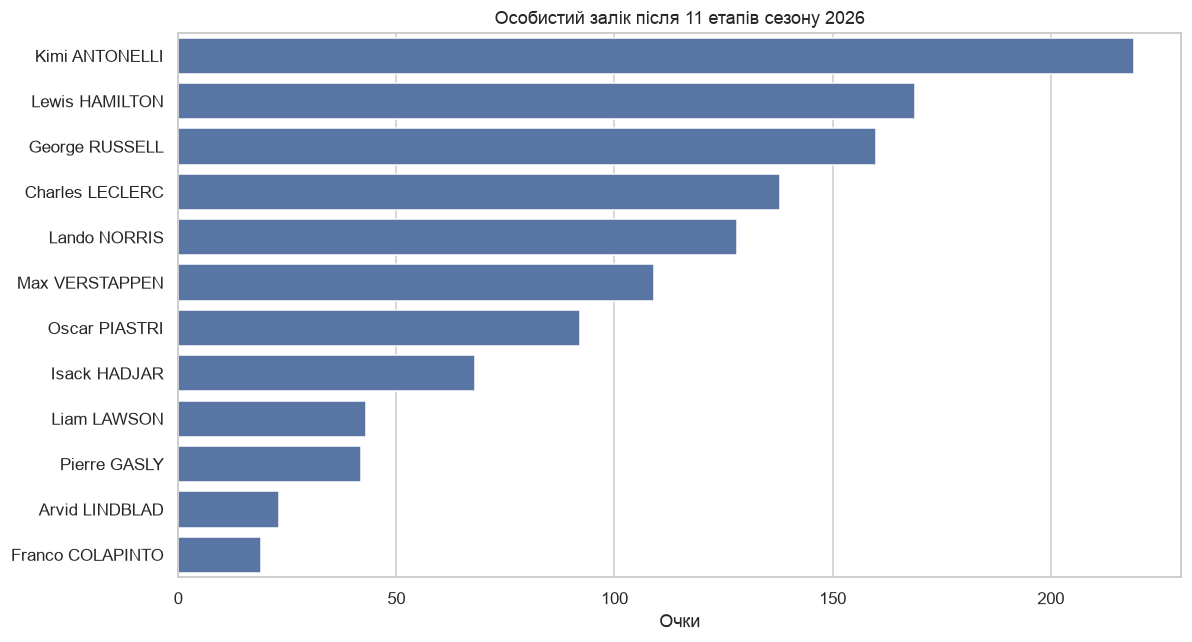

In [12]:
top12 = standings.head(12)

plt.figure(figsize=(11, 6))
sns.barplot(top12, y="full_name", x="points", color=BLUE)
plt.title("Особистий залік після 11 етапів сезону 2026")
plt.xlabel("Очки"); plt.ylabel("")
plt.tight_layout(); plt.show()

Лідирує Кімі Антонеллі — новачок, який за пів сезону набрав на 50 очок більше за найближчого
переслідувача. Расселл, його напарник по Mercedes, лише третій.

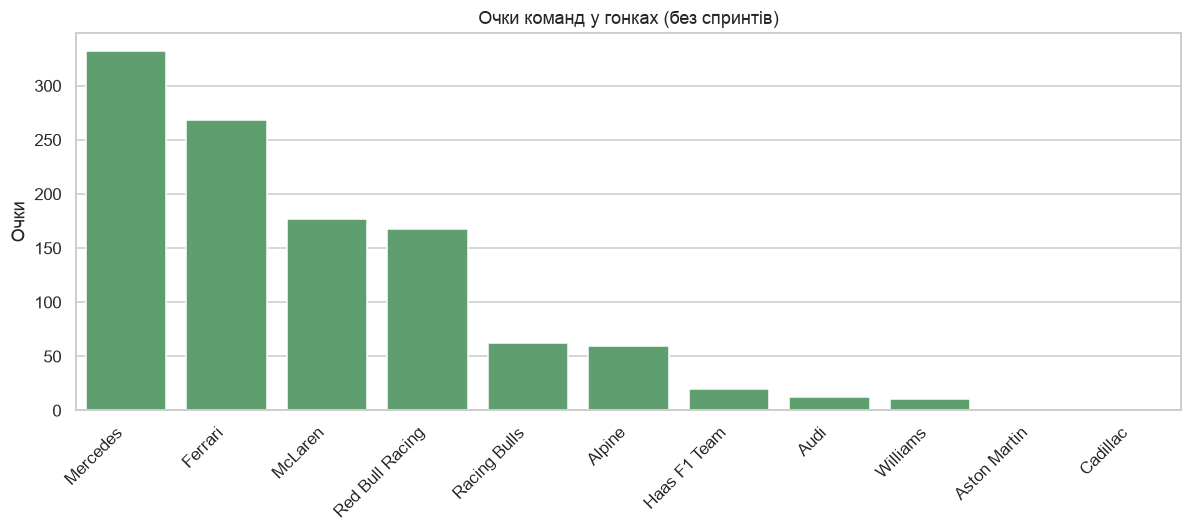

In [13]:
teams = (d26.groupby("team", as_index=False)["points"].sum()
         .sort_values("points", ascending=False))

plt.figure(figsize=(11, 5))
sns.barplot(teams, x="team", y="points", color=GREEN)
plt.title("Очки команд у гонках (без спринтів)")
plt.xticks(rotation=45, ha="right"); plt.xlabel(""); plt.ylabel("Очки")
plt.tight_layout(); plt.show()

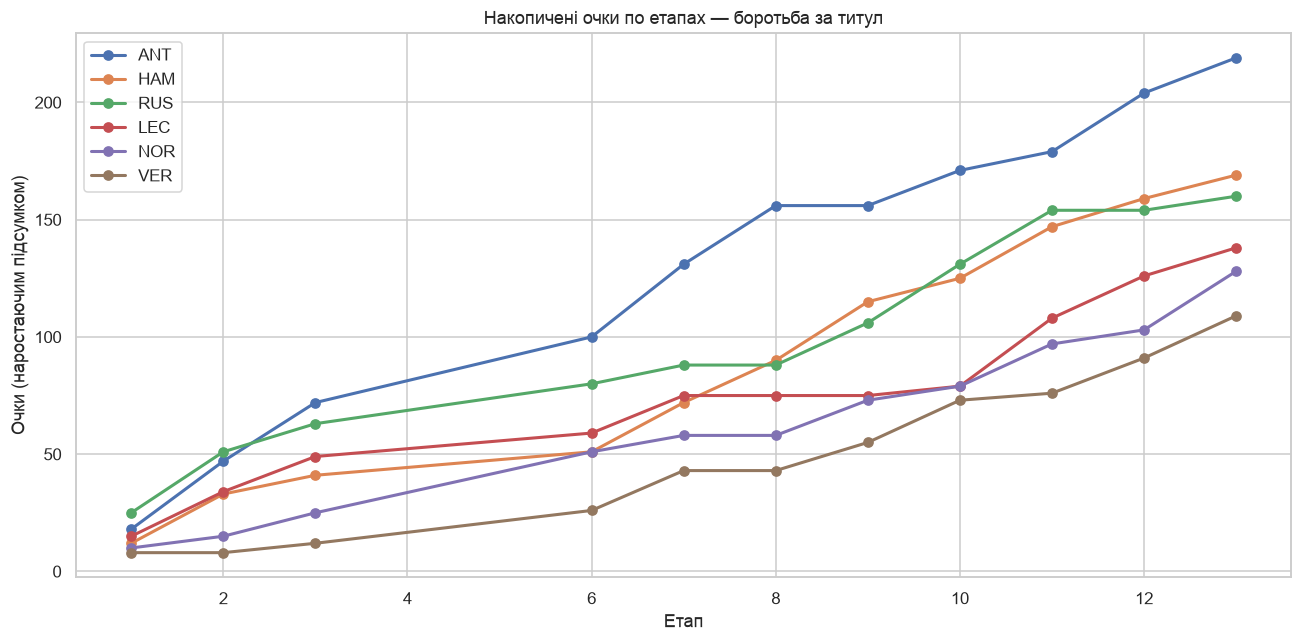

In [14]:
# Динаміка чемпіонату: як лідерство змінювалось по етапах
pivot = (points_by_round.pivot_table(index="round", columns="name_acronym",
                                     values="points", aggfunc="sum")
         .fillna(0).sort_index().cumsum())
leaders = standings.head(6)["name_acronym"].tolist()

plt.figure(figsize=(12, 6))
for code_ in leaders:
    plt.plot(pivot.index, pivot[code_], marker="o", linewidth=2, label=code_)
plt.title("Накопичені очки по етапах — боротьба за титул")
plt.xlabel("Етап"); plt.ylabel("Очки (наростаючим підсумком)")
plt.legend(); plt.tight_layout(); plt.show()

Антонеллі відривається не поступово, а ривком: приблизно з шостого етапу крива йде помітно крутіше
за решту. Расселл у тій самій машині за ним не встигає — а це вже питання не до боліда.

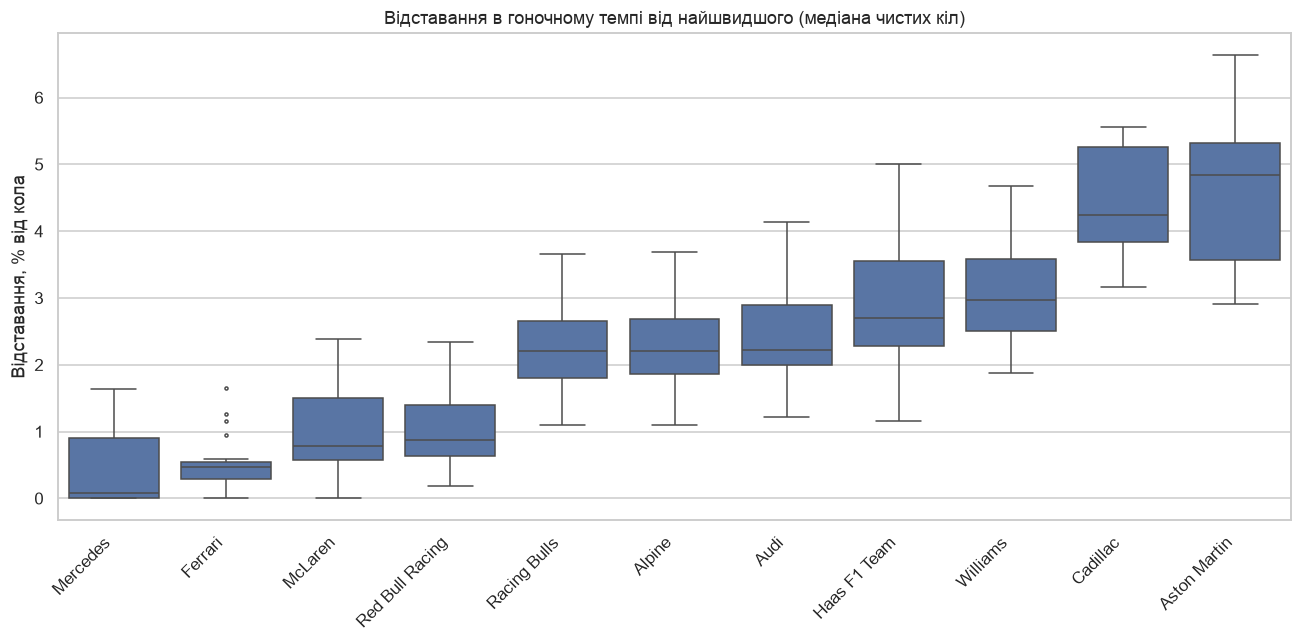

In [15]:
# Темп машин: медіана відставання у відсотках, щоб траси різної довжини були зіставні
pace = d26[d26["pace_reliable"]]
order = pace.groupby("team")["pace_gap_pct"].median().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(pace, x="team", y="pace_gap_pct", order=order, color=BLUE, fliersize=2)
plt.title("Відставання в гоночному темпі від найшвидшого (медіана чистих кіл)")
plt.xticks(rotation=45, ha="right"); plt.xlabel(""); plt.ylabel("Відставання, % від кола")
plt.tight_layout(); plt.show()

In [16]:
# Незалежна перевірка: те саме по кваліфікації, де немає ні палива, ні трафіку
q = (res_raw.merge(ses[["session_key", "session_name", "meeting_key", "year"]], on="session_key")
     .query("session_name == 'Qualifying' and year == 2026")
     .merge(mee_raw[["meeting_key", "round"]], on="meeting_key"))
q["best_q"] = q[["q1_s", "q2_s", "q3_s"]].min(axis=1)
q = q.dropna(subset=["best_q"])
q["q_gap_pct"] = (q["best_q"] - q.groupby("round")["best_q"].transform("min")) \
                 / q.groupby("round")["best_q"].transform("min") * 100
q = q.merge(d26[["round", "driver_number", "team"]].drop_duplicates(), on=["round", "driver_number"])

cmp = pd.DataFrame({
    "гонка":       pace.groupby("team")["pace_gap_pct"].median(),
    "кваліфікація": q.groupby("team")["q_gap_pct"].median(),
}).sort_values("гонка").round(2)
cmp

,гонка,кваліфікація
team,,
Mercedes,0.08,0.17
Ferrari,0.48,0.41
McLaren,0.78,0.60
Red Bull Racing,0.87,0.72
Racing Bulls,2.20,1.75
Alpine,2.20,2.05
Audi,2.22,1.83
Haas F1 Team,2.69,2.55
Williams,2.97,2.78


Два незалежні вимірювання збігаються: порядок команд однаковий, значення близькі.
Кваліфікація — це одне коло на мінімумі палива без трафіку, гонка — медіана десятків кіл;
те, що вони дають одне й те саме, означає, що фільтрація «чистих кіл» працює коректно.

Розрив між першою і останньою командою — близько **4.5% часу кола**. Для порівняння, у звичайний
сезон розкид становить приблизно 2%. Це прямий наслідок зміни регламенту.

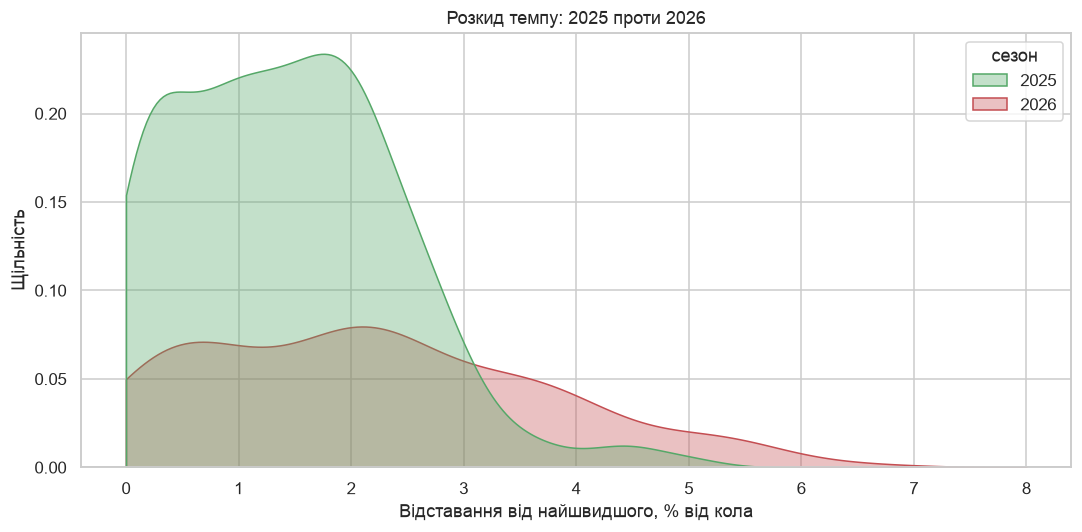

       mean   50%   max
сезон                  
2025   1.43  1.40  5.07
2026   2.18  2.05  6.63


In [17]:
# Чи справді 2026 розтягнутіший за 2025?
comp = pd.concat([
    d25[d25["pace_reliable"]].assign(сезон="2025"),
    d26[d26["pace_reliable"]].assign(сезон="2026"),
])

plt.figure(figsize=(10, 5))
sns.kdeplot(comp, x="pace_gap_pct", hue="сезон", fill=True, alpha=.35,
            palette=[GREEN, RED], clip=(0, 8))
plt.title("Розкид темпу: 2025 проти 2026")
plt.xlabel("Відставання від найшвидшого, % від кола"); plt.ylabel("Щільність")
plt.tight_layout(); plt.show()

print(comp.groupby("сезон")["pace_gap_pct"].describe()[["mean", "50%", "max"]].round(2))

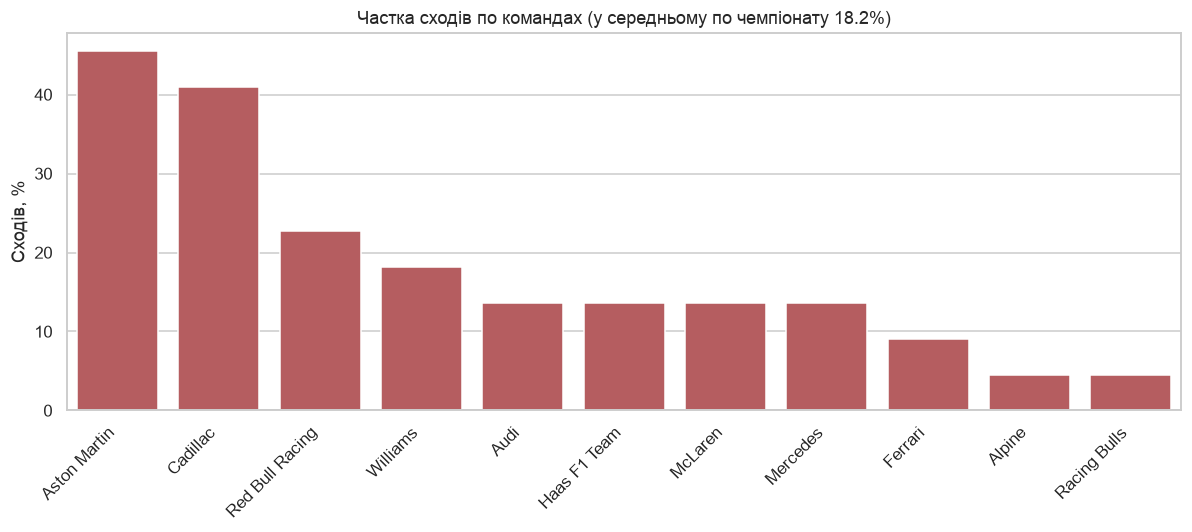

,стартів,сходів,частка
team,,,
Aston Martin,22,10,45.5
Cadillac,22,9,40.9
Red Bull Racing,22,5,22.7
Williams,22,4,18.2
Audi,22,3,13.6
Haas F1 Team,22,3,13.6
McLaren,22,3,13.6
Mercedes,22,3,13.6
Ferrari,22,2,9.1


In [18]:
# Сходи по командах — надійність за новим регламентом
rel = (d26.groupby("team")
       .agg(стартів=("dnf", "size"), сходів=("dnf", "sum"))
       .assign(частка=lambda x: (x["сходів"] / x["стартів"] * 100).round(1))
       .sort_values("частка", ascending=False))

plt.figure(figsize=(11, 5))
sns.barplot(rel.reset_index(), x="team", y="частка", color=RED)
plt.title(f"Частка сходів по командах (у середньому по чемпіонату {d26['dnf'].mean()*100:.1f}%)")
plt.xticks(rotation=45, ha="right"); plt.xlabel(""); plt.ylabel("Сходів, %")
plt.tight_layout(); plt.show()
rel

Сходи становлять **18%** стартів. Для сучасної Формули-1 це дуже багато — у стабільний регламент
показник тримається на рівні 7–8%. Прогноз, який ігнорує таку ненадійність, буде відірваний від дійсності.

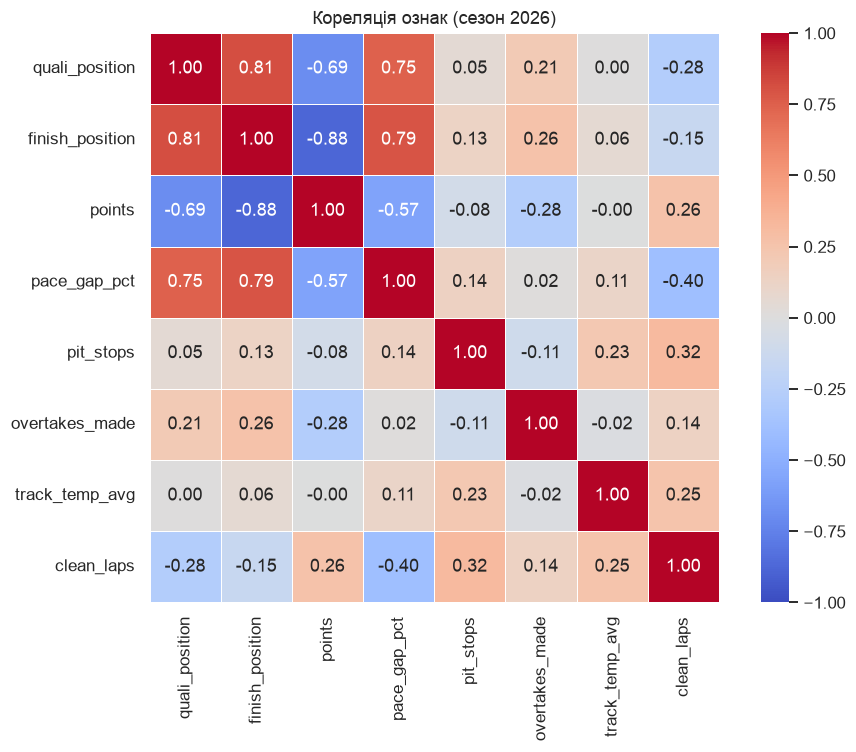

In [19]:
# Кореляційна матриця числових ознак
cols = ["quali_position", "finish_position", "points", "pace_gap_pct",
        "pit_stops", "overtakes_made", "track_temp_avg", "clean_laps"]
corr = d26[cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Кореляція ознак (сезон 2026)")
plt.tight_layout(); plt.show()

Найсильніший зв'язок — між стартовою позицією і фінішем. Темп корелює з результатом слабше,
ніж можна очікувати: справа в тому, що на результат впливають ще сходи й стратегія.
Температура траси не корелює майже ні з чим — до цього ще повернемось у гіпотезах.

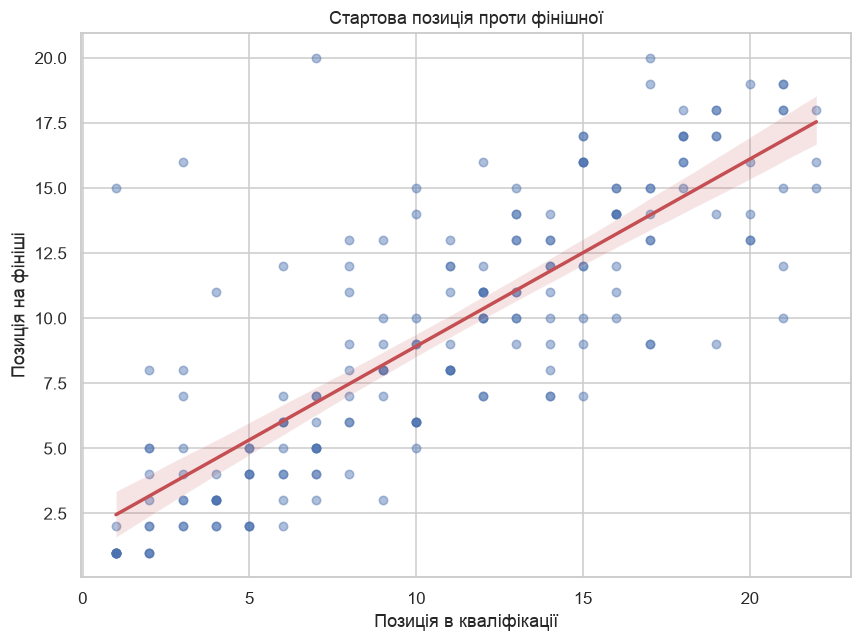

кореляція Спірмена: rho = 0.820, p = 5.82e-48


In [20]:
plt.figure(figsize=(8, 6))
sns.regplot(d26, x="quali_position", y="finish_position",
            scatter_kws={"alpha": .45, "s": 30}, line_kws={"color": RED})
plt.title("Стартова позиція проти фінішної")
plt.xlabel("Позиція в кваліфікації"); plt.ylabel("Позиція на фініші")
plt.tight_layout(); plt.show()

rho, p = stats.spearmanr(d26["quali_position"], d26["finish_position"], nan_policy="omit")
print(f"кореляція Спірмена: rho = {rho:.3f}, p = {p:.2e}")

## Частина 3: Перевірка Гіпотез

### Гіпотеза 1: висока температура траси підвищує кількість сходів

Поширена думка сезону: за новим регламентом машини перегріваються, і в спеку їх сходить більше.

**H0:** частка сходів не залежить від температури траси

**H1:** що вища температура траси, то більша частка сходів

Одиниця спостереження — **пілот у гонці**, а не гонка. На рівні гонок вибірка складає 11 точок,
на цьому рівні — 235. Наслідок бінарний (зійшов / не зійшов), тому t-тест тут неприйнятний:
потрібні критерії для часток.

In [21]:
h1 = d26.dropna(subset=["track_temp_avg"]).copy()
med_t = h1["track_temp_avg"].median()
h1["hot"] = h1["track_temp_avg"] >= med_t

print(f"спостережень: {len(h1)}, з них сходів: {int(h1['dnf'].sum())} ({h1['dnf'].mean()*100:.1f}%)")
print(f"медіана температури траси: {med_t:.1f}°C\n")

summary = (h1.groupby("hot")["dnf"].agg(стартів="size", сходів="sum")
           .assign(частка=lambda x: (x["сходів"] / x["стартів"] * 100).round(1)))
summary.index = ["холодніше медіани", "тепліше медіани"]
print(summary.to_string())

спостережень: 242, з них сходів: 44 (18.2%)
медіана температури траси: 37.0°C

                   стартів  сходів  частка
холодніше медіани      110      16    14.5
тепліше медіани        132      28    21.2


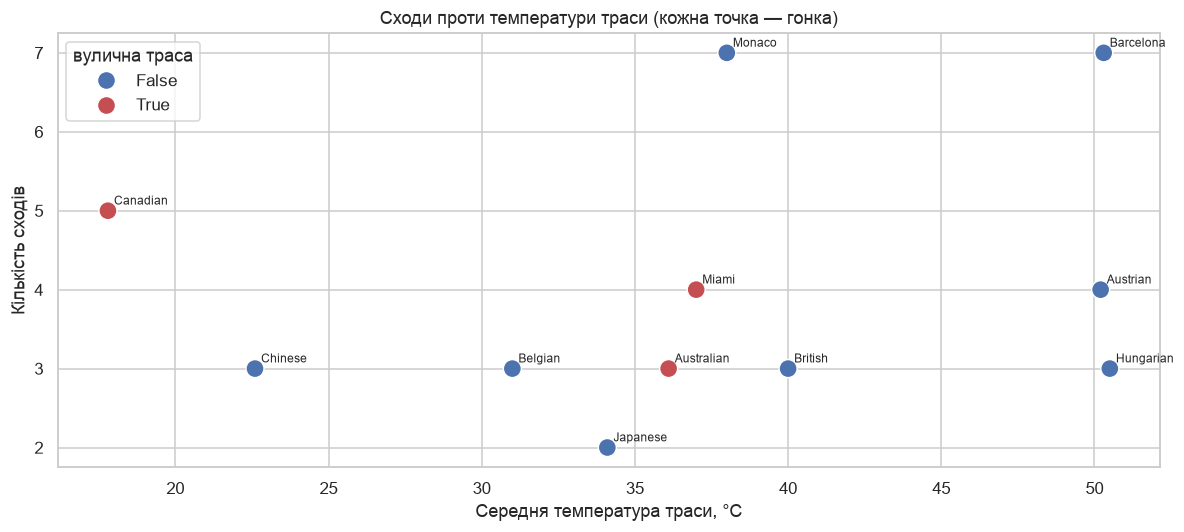

In [22]:
plt.figure(figsize=(11, 5))
per_race = (h1.groupby(["round", "meeting_name", "track_temp_avg", "is_street"], as_index=False)
            .agg(сходів=("dnf", "sum")))
sns.scatterplot(per_race, x="track_temp_avg", y="сходів", hue="is_street",
                s=140, palette={True: RED, False: BLUE})
for _, r in per_race.iterrows():
    plt.annotate(r["meeting_name"].replace(" Grand Prix", ""),
                 (r["track_temp_avg"], r["сходів"]), fontsize=8,
                 xytext=(4, 4), textcoords="offset points")
plt.title("Сходи проти температури траси (кожна точка — гонка)")
plt.xlabel("Середня температура траси, °C"); plt.ylabel("Кількість сходів")
plt.legend(title="вулична траса")
plt.tight_layout(); plt.show()

In [23]:
# Тест 1: таблиця спряженості. Правильний інструмент для бінарного наслідку.
table = pd.crosstab(h1["hot"], h1["dnf"])
chi2, p_chi, dof, expected = stats.chi2_contingency(table)
print("таблиця спряженості:\n", table.to_string(), "\n")
print(f"Тест 1 (хі-квадрат): chi2 = {chi2:.3f}, p = {p_chi:.4f}")

таблиця спряженості:
 dnf    False  True 
hot                
False     94     16
True     104     28 

Тест 1 (хі-квадрат): chi2 = 1.372, p = 0.2414


In [24]:
# Тест 2: точний тест Фішера — частина комірок мала, наближення хі-квадрата ненадійне.
tab = [[int(table.loc[True, True]),  int(table.loc[True, False])],
       [int(table.loc[False, True]), int(table.loc[False, False])]]
odds, p_fisher = stats.fisher_exact(tab, alternative="greater")
print(f"Тест 2 (точний тест Фішера): odds ratio = {odds:.3f}, p = {p_fisher:.4f}")

Тест 2 (точний тест Фішера): odds ratio = 1.582, p = 0.1203


In [25]:
# Тест 3: чи відрізняються самі температури в тих, хто зійшов і хто дійшов
u, p_mw = stats.mannwhitneyu(h1[h1["dnf"]]["track_temp_avg"],
                             h1[~h1["dnf"]]["track_temp_avg"],
                             alternative="greater")
print(f"Тест 3 (Манна-Уітні): U = {u:.0f}, p = {p_mw:.4f}")
print(f"  середня T у тих, хто зійшов: {h1[h1['dnf']]['track_temp_avg'].mean():.1f}°C")
print(f"  середня T у тих, хто дійшов: {h1[~h1['dnf']]['track_temp_avg'].mean():.1f}°C")

Тест 3 (Манна-Уітні): U = 4686, p = 0.2154
  середня T у тих, хто зійшов: 37.8°C
  середня T у тих, хто дійшов: 36.9°C


Тест 4 (перестановочний, 10 000): p = 0.1242
  спостережувана різниця часток: +6.7 в.п.
  95% нульового розподілу:       [-10.0, +10.0] в.п.


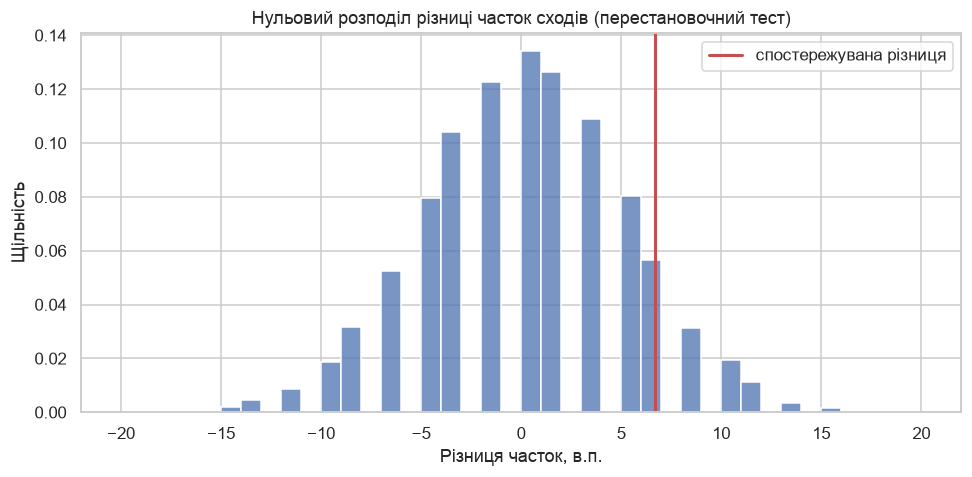

In [26]:
# Тест 4: перестановочний. Перемішуємо мітки сходів і дивимось, як часто
# випадковість дає різницю не меншу за спостережувану.
rng = np.random.default_rng(42)
observed = h1[h1["hot"]]["dnf"].mean() - h1[~h1["hot"]]["dnf"].mean()

labels = h1["dnf"].astype(bool).to_numpy()
is_hot = h1["hot"].to_numpy()
null = np.array([(lambda s: s[is_hot].mean() - s[~is_hot].mean())(rng.permutation(labels))
                 for _ in range(10_000)])
p_perm = (null >= observed).mean()
lo, hi = np.percentile(null, [2.5, 97.5])

print(f"Тест 4 (перестановочний, 10 000): p = {p_perm:.4f}")
print(f"  спостережувана різниця часток: {observed*100:+.1f} в.п.")
print(f"  95% нульового розподілу:       [{lo*100:+.1f}, {hi*100:+.1f}] в.п.")

plt.figure(figsize=(9, 4.5))
sns.histplot(null * 100, bins=40, color=BLUE, stat="density")
plt.axvline(observed * 100, color=RED, linewidth=2, label="спостережувана різниця")
plt.title("Нульовий розподіл різниці часток сходів (перестановочний тест)")
plt.xlabel("Різниця часток, в.п."); plt.ylabel("Щільність")
plt.legend(); plt.tight_layout(); plt.show()

In [27]:
# Тест 5: контроль типу траси. На вуличних сходять від контакту зі стіною,
# а не від перегріву — цей ефект може маскуватись під температурний.
perm_only = h1[~h1["is_street"]]
med2 = perm_only["track_temp_avg"].median()
hot2 = perm_only["track_temp_avg"] >= med2
tab2 = [[int((hot2 & perm_only["dnf"]).sum()),  int((hot2 & ~perm_only["dnf"]).sum())],
        [int((~hot2 & perm_only["dnf"]).sum()), int((~hot2 & ~perm_only["dnf"]).sum())]]
odds2, p_f2 = stats.fisher_exact(tab2, alternative="greater")

print(f"Тест 5 (тільки автодроми, без вуличних): p = {p_f2:.4f}, odds ratio = {odds2:.3f}")
print(f"  гаряче:  {perm_only[hot2]['dnf'].mean()*100:.1f}% сходів")
print(f"  холодно: {perm_only[~hot2]['dnf'].mean()*100:.1f}% сходів")
print(f"  n = {len(perm_only)}")

Тест 5 (тільки автодроми, без вуличних): p = 0.4227, odds ratio = 1.165
  гаряче:  19.3% сходів
  холодно: 17.0% сходів
  n = 176


**H0:** частка сходів не залежить від температури траси

**H1:** що вища температура траси, то більша частка сходів

| Тест | Результат |
|---|---|
| Тест 1 (хі-квадрат) | p = 0.241 → H0 не відхиляється |
| Тест 2 (точний тест Фішера) | p = 0.120, odds ratio = 1.58 → H0 не відхиляється |
| Тест 3 (Манна-Уітні) | p = 0.215 → H0 не відхиляється |
| Тест 4 (перестановочний) | p = 0.124 → H0 не відхиляється |
| Тест 5 (контроль типу траси) | p = 0.423, odds ratio = 1.17 → H0 не відхиляється |

**Висновок: H0 не відхиляється.** Зв'язок температури траси з кількістю сходів статистично не
підтверджується. Усі п'ять критеріїв узгоджені між собою.

Важлива деталь: напрямок ефекту правильний — у спеку сходить 21.2% проти 14.5% у прохолоду,
odds ratio 1.58. Але спостережувана різниця +6.7 в.п. лежить усередині 95% нульового розподілу,
тобто не відрізняється від випадкового шуму. Це не те саме, що «ефекту немає» — це «наявних
даних не вистачає, щоб його довести».

Тест 5 пояснює, звідки береться оманливе враження. Монако з 7 сходами при 38°C виглядає
підтвердженням гіпотези, поки не згадати, що це вулична траса, де сходять від зіткнень.
Після виключення вуличних трас ефект майже зникає: 19.3% проти 17.0%, а odds ratio падає
з 1.58 до 1.17. Те, що на око здається температурним ефектом, значною мірою є ефектом типу
траси — класичний прихований фактор.

### Гіпотеза 2: Антонеллі швидший за Расселла в одній і тій самій машині

Антонеллі лідирує в чемпіонаті, Расселл третій — але вони виступають за ту саму команду.
Порівняння напарників є єдиним чистим способом виміряти пілота окремо від боліда.

**H0:** медіанний темп Антонеллі й Расселла в гонках однаковий

**H1:** Антонеллі швидший

Спостереження парні (одна гонка — одна пара), тому потрібні парні критерії.

In [28]:
mer = (d26[(d26["team"] == "Mercedes") & d26["pace_reliable"]]
       .pivot_table(index="round", columns="driver_code", values="pace_gap")
       .dropna())
mer["різниця"] = mer["ANT"] - mer["RUS"]
print(mer.round(3).to_string())
print(f"\nсередня різниця: {mer['різниця'].mean():+.3f} с/коло")
print(f"медіанна різниця: {mer['різниця'].median():+.3f} с/коло")
print(f"гонок, де Антонеллі швидший: {(mer['різниця'] < 0).sum()} з {len(mer)}")

driver_code    ANT    RUS  різниця
round                             
1            0.000  0.070   -0.070
2            0.000  0.042   -0.042
3            0.000  0.551   -0.551
6            0.000  0.963   -0.963
7            0.000  0.738   -0.738
8            0.000  1.258   -1.258
9            0.731  0.861   -0.130
10           0.061  0.000    0.061
11           0.000  0.501   -0.501
13           0.632  0.757   -0.125

середня різниця: -0.432 с/коло
медіанна різниця: -0.315 с/коло
гонок, де Антонеллі швидший: 9 з 10


In [29]:
# Тест 1: парний t-критерій
t_stat, p_t = stats.ttest_rel(mer["ANT"], mer["RUS"], alternative="less")
print(f"Тест 1 (парний t-тест): t = {t_stat:.3f}, p = {p_t:.4f}")

# Тест 2: критерій знакових рангів Вілкоксона — без припущення про нормальність
w, p_w = stats.wilcoxon(mer["ANT"], mer["RUS"], alternative="less")
print(f"Тест 2 (Вілкоксон): W = {w:.1f}, p = {p_w:.4f}")

# Тест 3: бутстреп довірчого інтервалу різниці
rng = np.random.default_rng(42)
diffs = mer["різниця"].to_numpy()
boot = np.array([rng.choice(diffs, len(diffs), replace=True).mean() for _ in range(10_000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Тест 3 (бутстреп): 95% ДІ різниці = [{lo:.3f}, {hi:.3f}] с/коло")
print("  нуль поза інтервалом → різниця значуща" if hi < 0 or lo > 0
      else "  нуль усередині інтервалу → різниця не доведена")

Тест 1 (парний t-тест): t = -3.062, p = 0.0068
Тест 2 (Вілкоксон): W = 2.0, p = 0.0029


Тест 3 (бутстреп): 95% ДІ різниці = [-0.696, -0.182] с/коло
  нуль поза інтервалом → різниця значуща


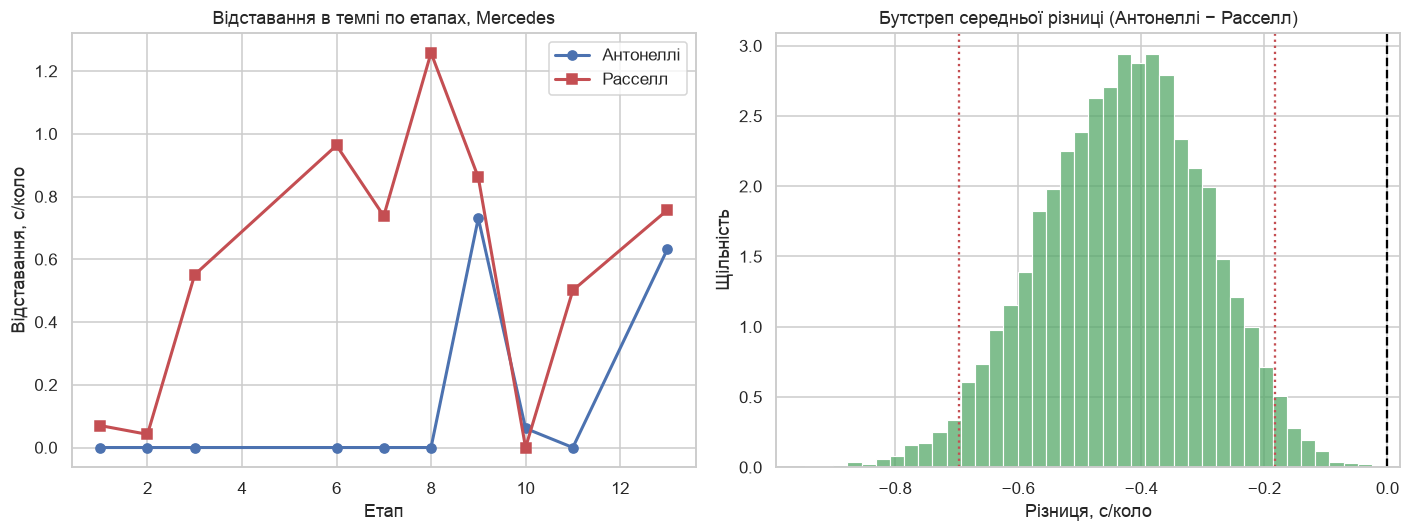

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(mer.index, mer["ANT"], marker="o", label="Антонеллі", color=BLUE, linewidth=2)
ax[0].plot(mer.index, mer["RUS"], marker="s", label="Расселл", color=RED, linewidth=2)
ax[0].set_title("Відставання в темпі по етапах, Mercedes")
ax[0].set_xlabel("Етап"); ax[0].set_ylabel("Відставання, с/коло"); ax[0].legend()

sns.histplot(boot, bins=40, color=GREEN, stat="density", ax=ax[1])
ax[1].axvline(0, color="black", linestyle="--", linewidth=1.5)
ax[1].axvline(lo, color=RED, linestyle=":"); ax[1].axvline(hi, color=RED, linestyle=":")
ax[1].set_title("Бутстреп середньої різниці (Антонеллі − Расселл)")
ax[1].set_xlabel("Різниця, с/коло"); ax[1].set_ylabel("Щільність")

plt.tight_layout(); plt.show()

In [31]:
# Той самий тест для всіх пар напарників — щоб побачити картину цілком
rows = []
for team, g in d26[d26["pace_reliable"]].groupby("team"):
    pv = g.pivot_table(index="round", columns="driver_code", values="pace_gap").dropna()
    if pv.shape[1] == 2 and len(pv) >= 5:
        a, b = pv.columns
        try:
            _, pw = stats.wilcoxon(pv[a], pv[b])
        except ValueError:
            pw = np.nan
        rows.append({"команда": team, "пара": f"{a} − {b}",
                     "різниця, с/коло": round((pv[a] - pv[b]).mean(), 3),
                     "гонок": len(pv), "p (Вілкоксон)": round(pw, 4)})

duels = pd.DataFrame(rows).sort_values("різниця, с/коло")
duels["значущо"] = np.where(duels["p (Вілкоксон)"] < 0.05, "так", "ні")
duels

,команда,пара,"різниця, с/коло",гонок,p (Вілкоксон),значущо
7,Mercedes,ANT − RUS,-0.432,10,0.0059,так
5,Haas F1 Team,BEA − OCO,-0.178,10,0.4316,ні
6,McLaren,NOR − PIA,-0.123,9,0.4961,ні
2,Audi,BOR − HUL,-0.077,8,0.7422,ні
8,Racing Bulls,LAW − LIN,-0.065,9,0.6328,ні
1,Aston Martin,ALO − STR,0.003,6,1.0000,ні
4,Ferrari,HAM − LEC,0.009,11,0.8477,ні
10,Williams,ALB − SAI,0.149,9,0.3594,ні
0,Alpine,COL − GAS,0.442,10,0.0137,так
9,Red Bull Racing,HAD − VER,0.451,8,0.0156,так


**H0:** медіанний темп Антонеллі й Расселла однаковий

**H1:** Антонеллі швидший

| Тест | Результат |
|---|---|
| Тест 1 (парний t-тест) | t = −3.06, p = 0.0068 → відхиляємо H0 |
| Тест 2 (Вілкоксон) | W = 2.0, p = 0.0029 → відхиляємо H0 |
| Тест 3 (бутстреп 95% ДІ) | [−0.696, −0.182] с/коло, нуль поза інтервалом |

**Висновок: H0 відхиляється.** Антонеллі швидший за Расселла в середньому на **0.432 с/коло**
в тій самій машині — і це підтверджують три незалежні критерії. Він виявився швидшим
у 9 гонках із 10.

Таблиця всіх дуелей додає до цього ще одне спостереження. Хемілтон і Леклер у Ferrari
розділені різницею 0.009 с/коло при p = 0.85 — за темпом вони не відрізняються взагалі.
Але в заліку Хемілтон другий, а Леклер четвертий, і розрив між ними 31 очко. Отже, ця різниця
породжена не швидкістю, а сходами й обставинами гонок.

Значущі дуелі знайшлись лише у трьох командах із одинадцяти: Mercedes, Alpine та Red Bull.
У решті напарники нерозрізненні — що зайвий раз показує, наскільки результат визначається
машиною, а не пілотом.

### Гіпотеза 3: на вуличних трасах стартова позиція важливіша

На вузьких вуличних трасах обганяти складніше, тому результат має сильніше визначатись
кваліфікацією.

**H0:** зв'язок стартової позиції з фінішною однаковий на вуличних трасах і на автодромах

**H1:** на вуличних трасах цей зв'язок сильніший

In [32]:
h3 = d26.dropna(subset=["quali_position", "finish_position"]).copy()

res_rows = []
for is_street, g in h3.groupby("is_street"):
    rho, p = stats.spearmanr(g["quali_position"], g["finish_position"])
    res_rows.append({"тип траси": "вулична" if is_street else "автодром",
                     "rho Спірмена": round(rho, 3), "p": f"{p:.2e}",
                     "спостережень": len(g),
                     "обгонів за гонку": round(g.groupby("round")["overtakes_made"].sum().mean(), 1)})
pd.DataFrame(res_rows)

,тип траси,rho Спірмена,p,спостережень,обгонів за гонку
0,автодром,0.809,1.42e-34,144,210.4
1,вулична,0.868,1.40e-15,48,205.7


In [33]:
# Перестановочний тест різниці кореляцій: перемішуємо мітку типу траси
street = h3[h3["is_street"]]; permanent = h3[~h3["is_street"]]
rho_s = stats.spearmanr(street["quali_position"], street["finish_position"]).statistic
rho_p = stats.spearmanr(permanent["quali_position"], permanent["finish_position"]).statistic
observed_diff = rho_s - rho_p

rng = np.random.default_rng(42)
mask = h3["is_street"].to_numpy()
qp = h3["quali_position"].to_numpy(); fp = h3["finish_position"].to_numpy()
null = []
for _ in range(10_000):
    m = rng.permutation(mask)
    null.append(stats.spearmanr(qp[m], fp[m]).statistic
                - stats.spearmanr(qp[~m], fp[~m]).statistic)
null = np.array(null)
p_perm3 = (np.abs(null) >= abs(observed_diff)).mean()

print(f"rho на вуличних:  {rho_s:.3f}")
print(f"rho на автодромах: {rho_p:.3f}")
print(f"різниця: {observed_diff:+.3f}")
print(f"перестановочний тест: p = {p_perm3:.4f}")

rho на вуличних:  0.868
rho на автодромах: 0.809
різниця: +0.059
перестановочний тест: p = 0.4937


<Figure size 1210x605 with 0 Axes>

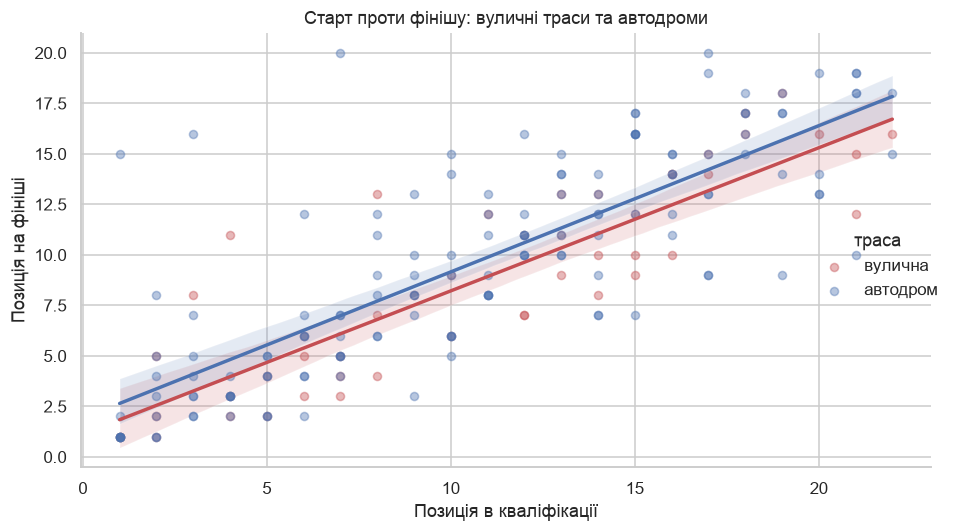

In [34]:
plt.figure(figsize=(11, 5.5))
sns.lmplot(data=h3.assign(траса=np.where(h3["is_street"], "вулична", "автодром")),
           x="quali_position", y="finish_position", hue="траса",
           palette={"вулична": RED, "автодром": BLUE},
           scatter_kws={"alpha": .4, "s": 28}, height=5, aspect=1.5)
plt.title("Старт проти фінішу: вуличні траси та автодроми")
plt.xlabel("Позиція в кваліфікації"); plt.ylabel("Позиція на фініші")
plt.tight_layout(); plt.show()

**H0:** зв'язок стартової позиції з фінішною однаковий на вуличних трасах і на автодромах

**H1:** на вуличних трасах цей зв'язок сильніший

| Тест | Результат |
|---|---|
| Кореляція Спірмена, вуличні | rho = 0.868 |
| Кореляція Спірмена, автодроми | rho = 0.809 |
| Перестановочний тест різниці | різниця +0.059, p = 0.494 → H0 не відхиляється |

**Висновок: H0 не відхиляється.** Різниця в напрямку, який передбачала гіпотеза, існує, але
вона мала і статистично незначуща.

Зате сам по собі зв'язок старту з фінішем виявився дуже сильним незалежно від типу траси:
rho = 0.82 по всій вибірці. За новим регламентом машини настільки різні за темпом, що
позиція, здобута в кваліфікації, майже повністю визначає результат — і вуличні траси тут
не виняток, а правило.

## Частина 4: Машинне Навчання та Прогноз

### 4.1 Побудова ознак

Головна вимога до ознак — вони мають бути відомі **до** гонки. Наприклад, медіанний темп у гонці
сильно корелює з результатом, але вимірюється під час самої гонки, тому в прогнозній моделі
це витік цільової змінної.

Форму пілота й темп команди рахуємо тільки за **попередніми** етапами через `shift(1)`.

In [35]:
feat = d26.sort_values(["driver", "round"]).copy()

# Форма пілота: середні очки за попередні гонки (без поточної)
feat["driver_form"] = (feat.groupby("driver")["points"]
                       .transform(lambda s: s.shift(1).expanding().mean()))

# Темп команди за попередніми етапами
team_pace = (feat.groupby(["team", "round"], as_index=False)["pace_gap_pct"].median()
             .sort_values(["team", "round"]))
team_pace["team_pace_prev"] = (team_pace.groupby("team")["pace_gap_pct"]
                               .transform(lambda s: s.shift(1).expanding().mean()))
feat = feat.merge(team_pace[["team", "round", "team_pace_prev"]], on=["team", "round"], how="left")

# Надійність команди за попередніми етапами
team_dnf = (feat.groupby(["team", "round"], as_index=False)["dnf"].mean()
            .sort_values(["team", "round"]))
team_dnf["team_dnf_prev"] = (team_dnf.groupby("team")["dnf"]
                             .transform(lambda s: s.shift(1).expanding().mean()))
feat = feat.merge(team_dnf[["team", "round", "team_dnf_prev"]], on=["team", "round"], how="left")

FEATURES_NUM = ["quali_position", "driver_form", "team_pace_prev", "team_dnf_prev", "track_temp_avg"]
FEATURES_CAT = ["team", "is_street"]
TARGET = "points"

model_df = feat.dropna(subset=["quali_position"]).copy()
model_df["is_street"] = model_df["is_street"].astype(str)
print("рядків для моделювання:", len(model_df))
model_df[FEATURES_NUM + FEATURES_CAT + [TARGET]].head()

рядків для моделювання: 238


,quali_position,driver_form,team_pace_prev,team_dnf_prev,track_temp_avg,team,is_street,points
0,15.0,NaN,NaN,NaN,36.1,Williams,True,0.0
1,18.0,0.00,2.969874,0.0,22.6,Williams,False,0.0
2,17.0,0.00,2.703057,0.0,34.1,Williams,False,0.0
3,15.0,0.00,2.820854,0.0,37.0,Williams,True,1.0
4,18.0,0.25,2.603229,0.0,17.8,Williams,True,0.0


In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])

X = model_df[FEATURES_NUM + FEATURES_CAT]
y = model_df[TARGET]
print("X:", X.shape, "| y:", y.shape)

X: (238, 7) | y: (238,)


**Розбиття на навчальну й тестову вибірки робимо за часом, а не випадково.** Задача прогнозна:
модель має передбачати майбутні гонки за минулими. Випадкове розбиття дало б їй підглядати
в майбутнє й завищило б оцінку якості.

In [37]:
rounds = sorted(model_df["round"].unique())
split_round = rounds[len(rounds) - 3]          # останні 3 етапи — тест

train_mask = model_df["round"] < split_round
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"навчальні етапи: {rounds[:len(rounds)-3]}  → {len(X_train)} рядків")
print(f"тестові етапи:   {rounds[len(rounds)-3:]}  → {len(X_test)} рядків")

навчальні етапи: [np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]  → 172 рядків
тестові етапи:   [np.int64(11), np.int64(12), np.int64(13)]  → 66 рядків


In [38]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(random_state=42, n_estimators=200),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results.append({"model": name,
                    "R2":   r2_score(y_test, pred),
                    "RMSE": rmse,
                    "MAE":  mean_absolute_error(y_test, pred)})
    print(f"{name:<20} R2={results[-1]['R2']:.3f}  RMSE={rmse:.2f}  MAE={results[-1]['MAE']:.2f}")

results = pd.DataFrame(results)

Linear Regression    R2=0.498  RMSE=4.96  MAE=3.15


Random Forest        R2=0.507  RMSE=4.91  MAE=2.86
Gradient Boosting    R2=0.447  RMSE=5.20  MAE=2.81


In [39]:
# Базовий орієнтир: передбачати кожному середні очки навчальної вибірки.
# Без нього незрозуміло, чи модель узагалі щось вміє.
baseline_pred = np.full(len(y_test), y_train.mean())
print(f"Базовий орієнтир (середнє): R2={r2_score(y_test, baseline_pred):.3f}  "
      f"RMSE={np.sqrt(mean_squared_error(y_test, baseline_pred)):.2f}")

Базовий орієнтир (середнє): R2=-0.000  RMSE=6.99


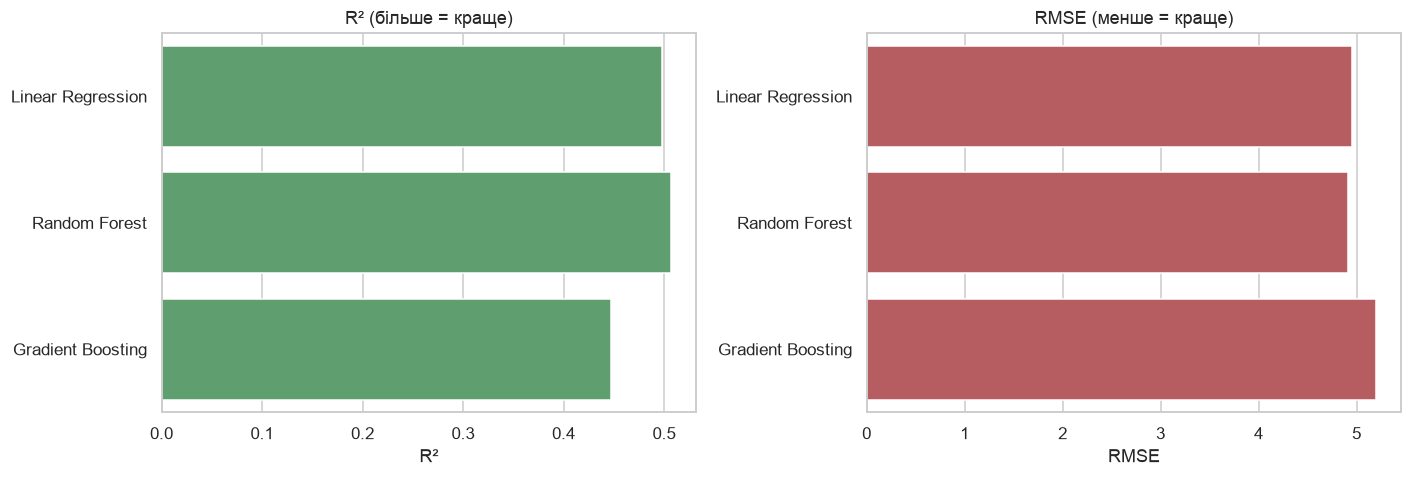

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(results, x="R2", y="model", color=GREEN, ax=ax[0])
ax[0].set_title("R² (більше = краще)"); ax[0].set_xlabel("R²"); ax[0].set_ylabel("")
sns.barplot(results, x="RMSE", y="model", color=RED, ax=ax[1])
ax[1].set_title("RMSE (менше = краще)"); ax[1].set_xlabel("RMSE"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

In [41]:
# Підбір гіперпараметрів для найкращої з моделей
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth":    [3, 5, 8, None],
    "model__min_samples_leaf": [1, 2, 4],
}
pipeline = Pipeline([("preprocessor", preprocessor),
                     ("model", RandomForestRegressor(random_state=42))])

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("найкращі параметри:", grid.best_params_)
print("найкращий R² (крос-валідація):", round(grid.best_score_, 3))

best_pred = grid.predict(X_test)
print("\nметрики на тестовій вибірці:")
print(f"  R²:   {r2_score(y_test, best_pred):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, best_pred)):.2f}")
print(f"  MAE:  {mean_absolute_error(y_test, best_pred):.2f}")

найкращі параметри: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
найкращий R² (крос-валідація): 0.25

метрики на тестовій вибірці:
  R²:   0.561
  RMSE: 4.63
  MAE:  2.81


In [42]:
# Крос-валідація фінальної моделі
final = grid.best_estimator_
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(final, X_train, y_train, cv=kf, scoring="r2")
print("R² по фолдах:", np.round(scores, 3))
print(f"середній R²: {scores.mean():.3f} (± {scores.std():.3f})")

R² по фолдах: [0.534 0.064 0.423 0.711 0.565]
середній R²: 0.459 (± 0.218)


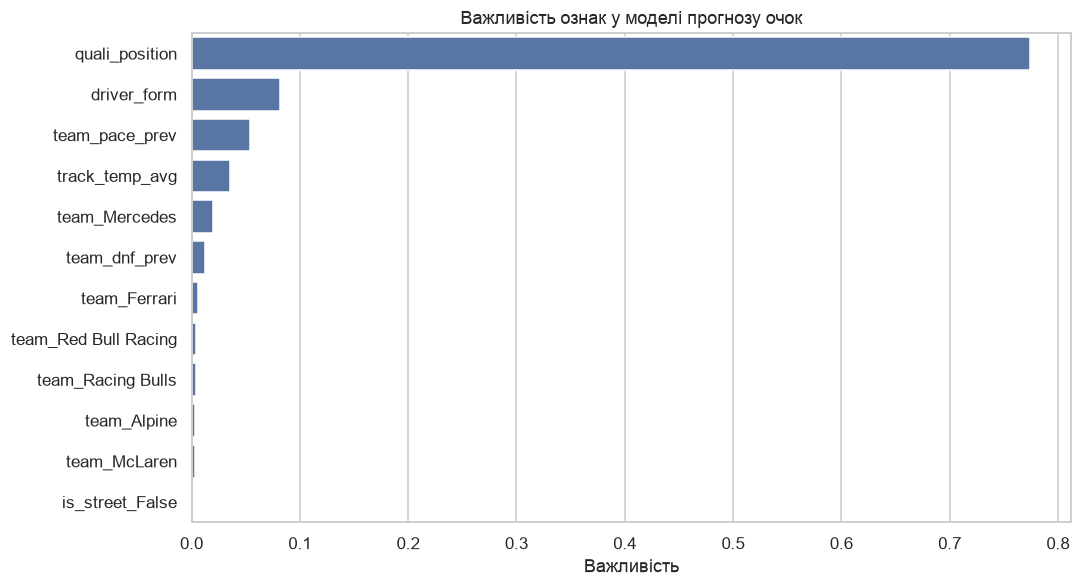

,ознака,важливість
0,quali_position,0.773711
1,driver_form,0.081378
2,team_pace_prev,0.054005
4,track_temp_avg,0.035154
12,team_Mercedes,0.020248
3,team_dnf_prev,0.012842


In [43]:
# Важливість ознак
ohe = final.named_steps["preprocessor"].named_transformers_["cat"]
feature_names = FEATURES_NUM + list(ohe.get_feature_names_out(FEATURES_CAT))
importance = pd.DataFrame({
    "ознака": feature_names,
    "важливість": final.named_steps["model"].feature_importances_,
}).sort_values("важливість", ascending=False).head(12)

plt.figure(figsize=(10, 5.5))
sns.barplot(importance, x="важливість", y="ознака", color=BLUE)
plt.title("Важливість ознак у моделі прогнозу очок")
plt.xlabel("Важливість"); plt.ylabel("")
plt.tight_layout(); plt.show()
importance.head(6)

### 4.2 Монте-Карло: симуляція решти сезону

Регресія передбачає очки за одну гонку. Але питання чемпіонату — не «скільки очок у наступній
гонці», а «хто виграє титул», і відповідь на нього не число, а ймовірність.

Тому решту сезону програємо багато разів. В одному прогоні для кожної з гонок, що лишились,
кожен пілот отримує випадковий результат із розподілу, побудованого на його реальному темпі, і
може зійти з власною ймовірністю. Підсумувавши очки, дивимось, хто став чемпіоном. Повторивши
20 000 разів, отримуємо частку прогонів — тобто ймовірність титулу.

**Шум розкладаємо на дві складові.** Невдалий вікенд буває у команди цілком, тому одна частина
шуму спільна для напарників, а друга — особиста. Модель, де збої пілотів незалежні,
недооцінює ризик.

In [44]:
pace_ok = d26[d26["pace_reliable"]].copy()

team_season = pace_ok.groupby("team")["pace_gap"].median().rename("team_base")
team_round  = pace_ok.groupby(["team", "round"])["pace_gap"].median().rename("team_round")
var = pace_ok.merge(team_season, on="team").merge(team_round, on=["team", "round"])
var["team_resid"]   = var["team_round"] - var["team_base"]
var["driver_resid"] = var["pace_gap"]   - var["team_round"]

SIGMA_TEAM   = var.drop_duplicates(["team", "round"])["team_resid"].std()
SIGMA_DRIVER = var["driver_resid"].std()

print(f"сигма командна (спільна для напарників): {SIGMA_TEAM:.3f} с/коло")
print(f"сигма особиста (в межах команди):        {SIGMA_DRIVER:.3f} с/коло")
print(f"частка дисперсії, що припадає на машину: "
      f"{SIGMA_TEAM**2 / (SIGMA_TEAM**2 + SIGMA_DRIVER**2) * 100:.0f}%")

сигма командна (спільна для напарників): 0.548 с/коло
сигма особиста (в межах команди):        0.265 с/коло
частка дисперсії, що припадає на машину: 81%


In [45]:
# Вхідні дані симуляції
strength = pace_ok.groupby("driver_code")["pace_gap"].median()
team_of  = d26.drop_duplicates("driver_code").set_index("driver_code")["team"]

# Ймовірність сходу зі згладжуванням до середнього по полю: 11 гонок замало,
# щоб довіряти сирій частці окремого пілота.
dnf_counts = d26.groupby("driver_code")["dnf"].agg(["sum", "count"]).astype(float)
PRIOR = float(d26["dnf"].mean()); K = 5.0
p_dnf = (dnf_counts["sum"] + K * PRIOR) / (dnf_counts["count"] + K)

current = (points_by_round.groupby("name_acronym")["points"].sum())

drivers = sorted(set(strength.index) & set(p_dnf.index) & set(current.index))
print(f"пілотів у симуляції: {len(drivers)}")
print(f"середня ймовірність сходу по полю: {PRIOR:.3f}")

pd.DataFrame({"темп, с/коло": strength.loc[drivers].round(3),
              "p(схід)": p_dnf.loc[drivers].round(3),
              "очки зараз": current.loc[drivers]}).sort_values("темп, с/коло").head(8)

пілотів у симуляції: 22
середня ймовірність сходу по полю: 0.182


,"темп, с/коло",p(схід),очки зараз
ANT,0.000,0.119,219.0
HAM,0.363,0.057,169.0
LEC,0.399,0.182,138.0
VER,0.553,0.244,109.0
NOR,0.639,0.182,128.0
RUS,0.645,0.182,160.0
PIA,0.761,0.119,92.0
HAD,0.983,0.182,68.0


In [46]:
# Скільки гонок і спринтів лишилось
TODAY = "2026-08-19"
future = sess[sess["date_start"] > TODAY]
N_RACES   = int((future["session_name"] == "Race").sum())
N_SPRINTS = int((future["session_name"] == "Sprint").sum())
print(f"попереду гонок: {N_RACES}, спринтів: {N_SPRINTS}")

PTS_RACE   = np.array([25, 18, 15, 12, 10, 8, 6, 4, 2, 1])
PTS_SPRINT = np.array([8, 7, 6, 5, 4, 3, 2, 1])

попереду гонок: 12, спринтів: 2


In [47]:
def simulate(n_sims=20_000, seed=42):
    rng = np.random.default_rng(seed)
    base   = strength.loc[drivers].to_numpy()
    risk   = p_dnf.loc[drivers].to_numpy()
    teams  = pd.Categorical(team_of.loc[drivers]).codes
    n_teams = teams.max() + 1
    totals = np.tile(current.loc[drivers].to_numpy().astype(float), (n_sims, 1))
    rows = np.arange(n_sims)[:, None]

    for n_events, table in ((N_RACES, PTS_RACE), (N_SPRINTS, PTS_SPRINT)):
        for _ in range(n_events):
            # спільний для напарників зсув команди на цих вихідних
            team_shock = rng.normal(0, SIGMA_TEAM, size=(n_sims, n_teams))[:, teams]
            personal   = rng.normal(0, SIGMA_DRIVER, size=(n_sims, len(drivers)))
            perf = base + team_shock + personal

            retired = rng.random((n_sims, len(drivers))) < risk
            perf = np.where(retired, np.inf, perf)      # схід — у кінець класифікації

            order  = np.argsort(perf, axis=1)
            gained = np.zeros((n_sims, len(drivers)))
            k = len(table)
            gained[rows, order[:, :k]] = table
            gained[retired] = 0                          # той, хто зійшов, очок не отримує
            totals += gained
    return totals

totals = simulate()
champion = np.array(drivers)[np.argmax(totals, axis=1)]
title_prob = (pd.Series(champion).value_counts(normalize=True) * 100).round(1)
print("=== ЙМОВІРНІСТЬ ТИТУЛУ ===")
print(title_prob.head(8).to_string())

=== ЙМОВІРНІСТЬ ТИТУЛУ ===
ANT    97.5
HAM     2.5
LEC     0.0


In [48]:
proj = pd.DataFrame({
    "пілот":        drivers,
    "очки зараз":   current.loc[drivers].to_numpy(),
    "прогноз очок": totals.mean(axis=0).round(0),
    "5-й перцентиль":  np.percentile(totals, 5, axis=0).round(0),
    "95-й перцентиль": np.percentile(totals, 95, axis=0).round(0),
    "шанс на титул, %": [title_prob.get(d, 0.0) for d in drivers],
}).sort_values("прогноз очок", ascending=False).head(8).reset_index(drop=True)
proj

,пілот,очки зараз,прогноз очок,5-й перцентиль,95-й перцентиль,"шанс на титул, %"
0,ANT,219.0,433.0,382.0,480.0,97.5
1,HAM,169.0,347.0,306.0,387.0,2.5
2,LEC,138.0,285.0,240.0,331.0,0.0
3,RUS,160.0,277.0,239.0,316.0,0.0
4,NOR,128.0,254.0,212.0,296.0,0.0
5,VER,109.0,235.0,190.0,282.0,0.0
6,PIA,92.0,211.0,174.0,250.0,0.0
7,HAD,68.0,155.0,122.0,191.0,0.0


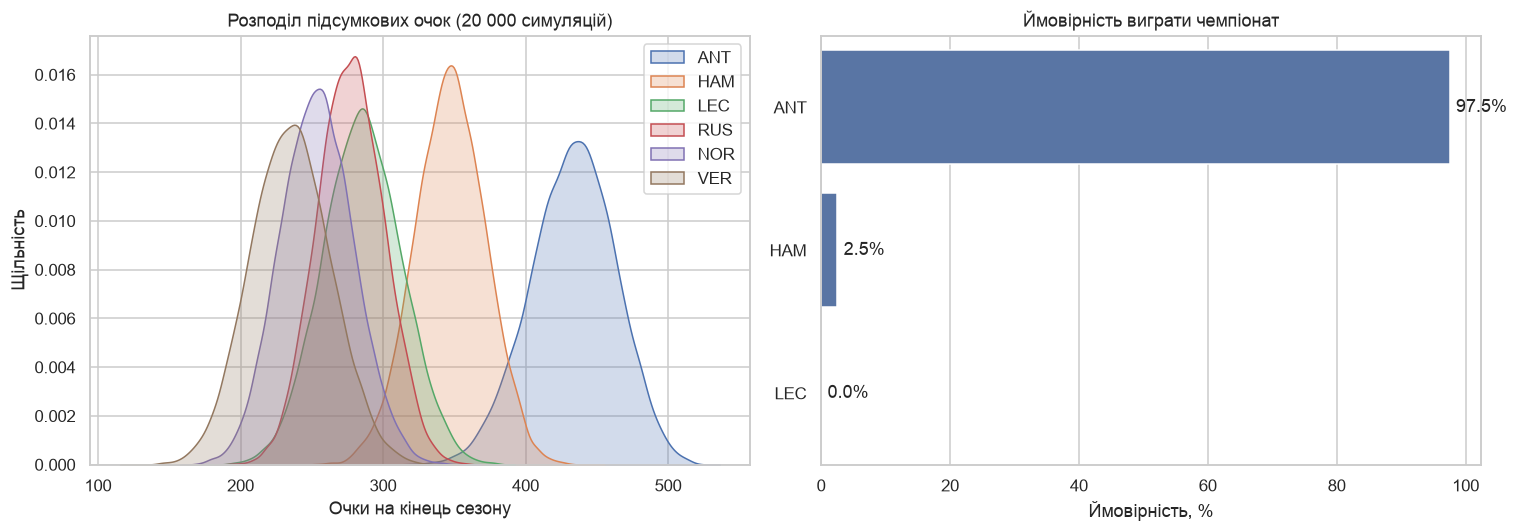

In [49]:
top6 = proj.head(6)["пілот"].tolist()
idx = [drivers.index(d) for d in top6]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for d, i in zip(top6, idx):
    sns.kdeplot(totals[:, i], label=d, fill=True, alpha=.25, ax=ax[0])
ax[0].set_title("Розподіл підсумкових очок (20 000 симуляцій)")
ax[0].set_xlabel("Очки на кінець сезону"); ax[0].set_ylabel("Щільність"); ax[0].legend()

probs = title_prob.head(6)
sns.barplot(x=probs.values, y=probs.index, color=BLUE, ax=ax[1])
ax[1].set_title("Ймовірність виграти чемпіонат")
ax[1].set_xlabel("Ймовірність, %"); ax[1].set_ylabel("")
for i, v in enumerate(probs.values):
    ax[1].text(v + 1, i, f"{v}%", va="center")

plt.tight_layout(); plt.show()

#### Наскільки можна довіряти цій цифрі

97.5% — дуже впевнений прогноз, і саме тому його треба перевірити на стійкість. Модель могла
занизити невизначеність, бо вважає темп команд незмінним до кінця сезону, хоча насправді
машини розвиваються, і Ferrari чи McLaren можуть підтягнутись.

Перерахуємо симуляцію за песимістичніших припущень: більший розкид результатів і вища
аварійність. Якщо висновок вистоїть — на нього можна спиратись.

In [50]:
scenarios = {
    "базовий":                      (1.0, 1.0),
    "розкид +50%":                  (1.5, 1.0),
    "аварійність +50%":             (1.0, 1.5),
    "розкид +50% і аварійність +50%": (1.5, 1.5),
    "розкид удвічі":                (2.0, 1.0),
}

base_sigma_team, base_sigma_driver, base_pdnf = SIGMA_TEAM, SIGMA_DRIVER, p_dnf.copy()
rows = []
for name, (k_sigma, k_dnf) in scenarios.items():
    SIGMA_TEAM   = base_sigma_team * k_sigma
    SIGMA_DRIVER = base_sigma_driver * k_sigma
    p_dnf        = (base_pdnf * k_dnf).clip(upper=0.6)
    tot = simulate(n_sims=10_000, seed=7)
    champ = np.array(drivers)[np.argmax(tot, axis=1)]
    share = pd.Series(champ).value_counts(normalize=True) * 100
    rows.append({"сценарій": name,
                 "ANT, %": round(share.get("ANT", 0), 1),
                 "HAM, %": round(share.get("HAM", 0), 1),
                 "інші, %": round(100 - share.get("ANT", 0) - share.get("HAM", 0), 1)})

SIGMA_TEAM, SIGMA_DRIVER, p_dnf = base_sigma_team, base_sigma_driver, base_pdnf
pd.DataFrame(rows)

,сценарій,"ANT, %","HAM, %","інші, %"
0,базовий,97.4,2.5,0.0
1,розкид +50%,95.3,4.6,0.1
2,аварійність +50%,94.4,5.6,0.0
3,розкид +50% і аварійність +50%,92.2,7.7,0.1
4,розкид удвічі,93.6,6.2,0.2


### 4.3 Перевірка чужого прогнозу на реальних даних

Навесні 2026 року, після першого етапу, вже публікувався аналітичний прогноз на сезон.
Він будувався на результатах однієї гонки та історичній кореляції «переможець Австралії → чемпіон».
Тепер, маючи половину сезону, його можна перевірити — можливості, якої в березні не існувало.

In [51]:
march = pd.DataFrame([
    {"показник": "Чемпіон",         "прогноз (березень)": "Расселл (45%)",  "факт після 11 етапів": None},
    {"показник": "2-е місце",       "прогноз (березень)": "Леклер (30%)",   "факт після 11 етапів": None},
    {"показник": "3-є місце",       "прогноз (березень)": "Ферстаппен (15%)", "факт після 11 етапів": None},
    {"показник": "Кубок конструкторів", "прогноз (березень)": "Mercedes (65%)", "факт після 11 етапів": None},
    {"показник": "Сенсація сезону", "прогноз (березень)": "Haas",           "факт після 11 етапів": None},
])

order = standings.reset_index(drop=True)
teams_now = d26.groupby("team")["points"].sum().sort_values(ascending=False)
march.loc[0, "факт після 11 етапів"] = f"{order.loc[0, 'name_acronym']} ({int(order.loc[0, 'points'])} очок)"
march.loc[1, "факт після 11 етапів"] = f"{order.loc[1, 'name_acronym']} ({int(order.loc[1, 'points'])} очок)"
march.loc[2, "факт після 11 етапів"] = f"{order.loc[2, 'name_acronym']} ({int(order.loc[2, 'points'])} очок)"
march.loc[3, "факт після 11 етапів"] = f"{teams_now.index[0]} (лідирує)"
march.loc[4, "факт після 11 етапів"] = f"Haas — {list(teams_now.index).index('Haas F1 Team')+1}-е місце"

russell_place = int(order.index[order["name_acronym"] == "RUS"][0]) + 1
print(f"Расселл, якого прогнозували в чемпіони, зараз {russell_place}-й\n")
march

Расселл, якого прогнозували в чемпіони, зараз 3-й



,показник,прогноз (березень),факт після 11 етапів
0,Чемпіон,Расселл (45%),ANT (219 очок)
1,2-е місце,Леклер (30%),HAM (169 очок)
2,3-є місце,Ферстаппен (15%),RUS (160 очок)
3,Кубок конструкторів,Mercedes (65%),Mercedes (лідирує)
4,Сенсація сезону,Haas,Haas — 7-е місце


Березневий прогноз вгадав команду й помилився з пілотом. Причина методологічна: він спирався на
результат однієї гонки, а Расселл виграв саме її. Показник «переможець Австралії → чемпіон»
має історичну справджуваність близько 40% — тобто це підкидання монети, а не прогноз.

Наша модель уникає цієї помилки, бо оцінює темп за десятками кіл у кожній гонці, а не за одним
підсумком, і відокремлює швидкість пілота від швидкості машини через порівняння напарників.

## Висновки

**1. Регламент справді все перекроїв.** Розрив між найшвидшою і найповільнішою командою становить
близько **4.8% часу кола** проти звичних ~2%. Це підтверджують два незалежні вимірювання —
гоночний темп (4.84%) і кваліфікація (4.67%). Спиратись на дані попередніх сезонів у такий рік не можна.

**2. Машина важить приблизно вчетверо більше за пілота.** Розклад дисперсії темпу показує:
командна складова дає 0.548 с/коло, особиста — 0.265 с/коло, тобто на болід припадає близько
**81% дисперсії**. Значущу перевагу над напарником знайдено лише в 3 командах з 11.

**3. Антонеллі виграє в напарника за швидкістю, а не за везінням.** Перевага 0.432 с/коло в тій
самій машині підтверджена трьома незалежними критеріями (p = 0.003…0.007), він швидший
у 9 гонках із 10. Натомість Хемілтон і Леклер за темпом не відрізняються взагалі
(0.009 с/коло, p = 0.85) — їхні 31 очко різниці породжені сходами й обставинами, а не швидкістю.

**4. Гіпотеза про спеку не підтвердилась.** Жоден із п'яти критеріїв не виявив значущого зв'язку
температури траси зі сходами. Те, що виглядало температурним ефектом, значною мірою виявилось
ефектом типу траси: після виключення вуличних автодромів odds ratio падає з 1.58 до 1.17.
Напрямок ефекту при цьому правильний, але 242 спостережень замало, щоб відрізнити його від шуму.

**5. Стартова позиція вирішує майже все.** rho = 0.82 між кваліфікацією і фінішем. Гіпотеза, що
на вуличних трасах цей зв'язок сильніший, не підтвердилась (p = 0.49) — він однаково сильний
скрізь, бо машини надто різні за темпом, щоб відіграватись у гонці.

**6. Надійність — головний ризик сезону.** 18.2% сходів проти звичних 7–8%. Саме тому прогноз
будується як розподіл, а не як одне число.

**7. Прогноз: Антонеллі — чемпіон із ймовірністю близько 97%**, і цей висновок витримує
перевірку на стійкість: навіть при подвоєному розкиді результатів і півторакратно збільшеній
аварійності він лишається впевненим фаворитом.

### Обмеження роботи

- 11 гонок — це мало. Довірчі інтервали широкі, і в симуляції це видно.
- Причини сходів у даних немає, тільки сам факт. Тому гіпотезу про перегрів неможливо
  перевірити прямо — лише через частоту сходів.
- **Модель вважає темп команд незмінним до кінця сезону.** Це найсуттєвіше спрощення:
  машини розвиваються нерівномірно, і команда, яка знайде секунду, зламає прогноз.
  Саме тому 97% варто читати як «за умови, що розстановка сил збережеться», а не як
  абсолютну ймовірність.
- Погода в майбутніх гонках невідома; симуляція неявно припускає умови, схожі на середні.
- Симуляція не моделює аварії за участю кількох машин, зіткнення й тактичні рішення команд.